In [1]:
import numpy as np
import pandas as pd
import scipy.stats as stats
import matplotlib.pyplot as plt

In [2]:
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.graphics.tsaplots import plot_pacf 

In [3]:
import statsmodels.api as sm
from statsmodels.stats.diagnostic import het_white
from statsmodels.stats.diagnostic import acorr_ljungbox

In [4]:
adx_data= pd.read_csv('C:\\Users\\moham\\Desktop\\محلد تحليلات بحث التخرج\\الرسوم البيانية واختبارات الارتباط الذاتي\\ADX.csv',
              parse_dates =[0], index_col=[0])

In [5]:
adx_data

,Open,High,Low,Close,Adj Close,Volume
Date,,,,,,
2018-01-02,15.120000,15.130000,15.080000,15.100000,9.623001,192100
2018-01-03,15.130000,15.220000,15.120000,15.220000,9.699475,204000
2018-01-04,15.230000,15.350000,15.230000,15.350000,9.782323,157400
2018-01-05,15.400000,15.400000,15.310000,15.380000,9.801441,215900
2018-01-08,15.360000,15.420000,15.350000,15.420000,9.826931,221800
...,...,...,...,...,...,...
2023-12-22,17.570000,17.719999,17.530001,17.580000,17.489521,231500
2023-12-26,17.580000,17.750000,17.580000,17.730000,17.638748,95100
2023-12-27,17.670000,17.770000,17.670000,17.760000,17.668596,131900


In [6]:
adx_data.isnull().sum()

Open         0
High         0
Low          0
Close        0
Adj Close    0
Volume       0
dtype: int64

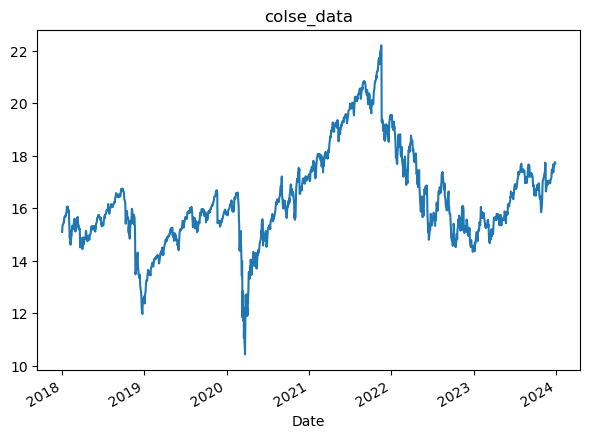

In [7]:
adx_data['Close'].plot(title='colse_data',
                      figsize=(7,5));

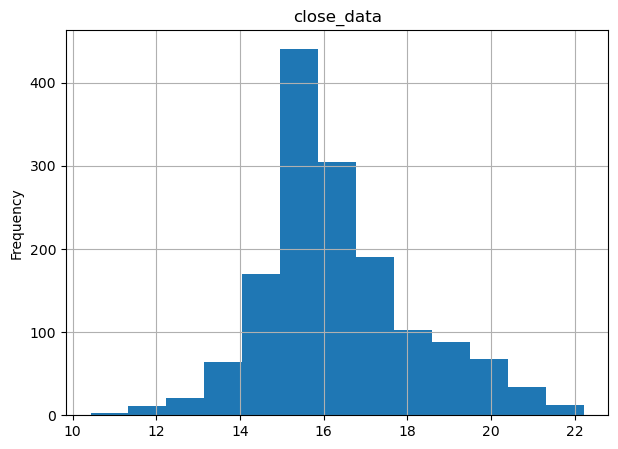

In [8]:
adx_data['Close'].plot(kind='hist',bins=13,figsize=(7,5),grid=True,title='close_data');

In [9]:
adx_data['Close'].describe()

count    1509.000000
mean       16.355580
std         1.819822
min        10.430000
25%        15.260000
50%        15.950000
75%        17.260000
max        22.209999
Name: Close, dtype: float64

In [10]:
adx_data['Close'].var()

3.3117502941401167

In [11]:
adx_data['Close'].skew()

0.5948340155436004

In [12]:
adx_data['Close'].kurt()

0.5367296273565949

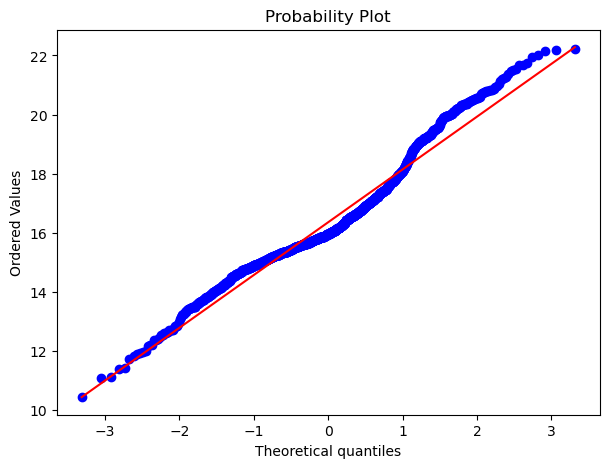

In [13]:
plt.subplots(figsize=(7, 5))
stats.probplot(adx_data['Close'],dist='norm',plot=plt);

In [14]:
stats.shapiro(adx_data['Close'])

ShapiroResult(statistic=0.960946883367753, pvalue=1.0441840050817922e-19)

In [15]:
stats.jarque_bera(adx_data['Close'])

SignificanceResult(statistic=106.53766138460017, pvalue=7.339065654944262e-24)

In [16]:
y= adx_data['Close']
x= np.arange(len(y))
x= sm.add_constant(x) 

model = sm.OLS(y,x).fit() 

white_test = het_white(model.resid ,model.model.exog)

In [17]:
white_test

(203.85191270717522,
 5.4215016330338675e-45,
 117.61155056886919,
 3.458002155781166e-48)

In [18]:
adfuller(adx_data['Close'])

(-2.3517090369345843,
 0.15583238681831107,
 9,
 1499,
 {'1%': -3.4347199356122493,
  '5%': -2.86347004827819,
  '10%': -2.567797534300163},
 -352.67752477952536)

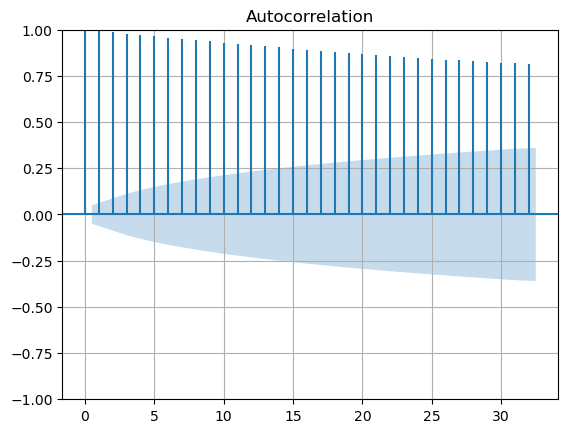

In [19]:
plot_acf(adx_data['Close'],marker='')
plt.grid()

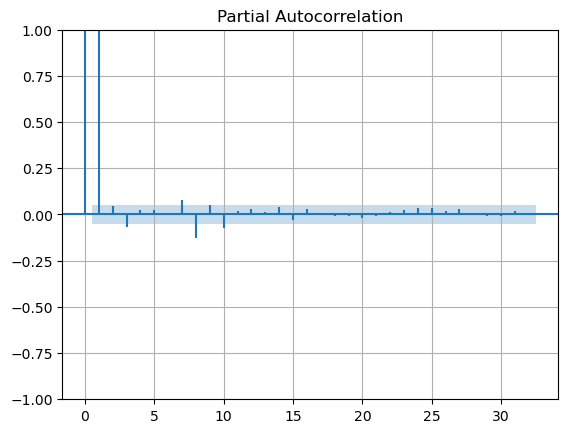

In [20]:
plot_pacf(adx_data['Close'],marker='')
plt.grid()

In [21]:
adx_data['Close_log']= adx_data['Close'].apply(np.log)

In [22]:
adx_data['Close_log_diff']= adx_data['Close_log'].diff()

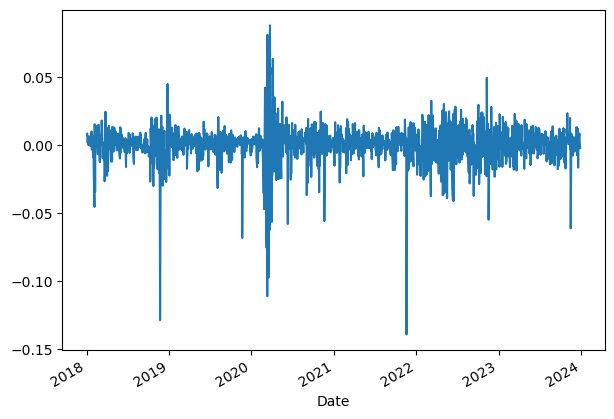

In [23]:
adx_data['Close_log_diff'][1:].plot(figsize=(7,5));

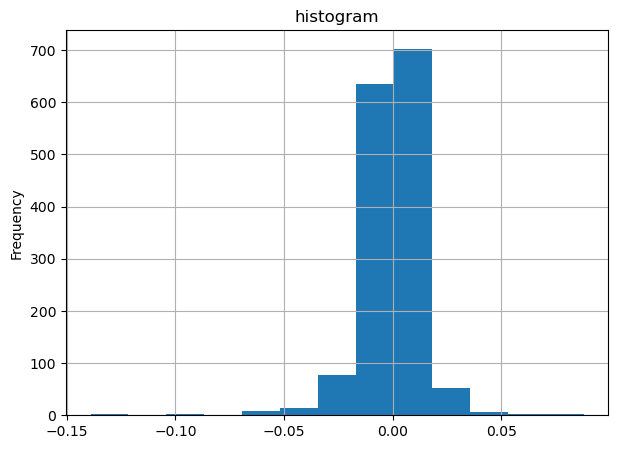

In [24]:
adx_data['Close_log_diff'][1:].plot(kind='hist',bins=13,figsize=(7,5),grid=True)
plt.title('histogram');

In [25]:
adx_data['Close_log_diff'][1:].describe()

count    1508.000000
mean        0.000106
std         0.014124
min        -0.139086
25%        -0.004601
50%         0.001139
75%         0.006512
max         0.088050
Name: Close_log_diff, dtype: float64

In [26]:
adx_data['Close_log_diff'][1:].var()

0.000199496468943724

In [27]:
adx_data['Close_log_diff'][1:].skew()

-2.0169696365590437

In [28]:
adx_data['Close_log_diff'][1:].kurt()

19.45062935344668

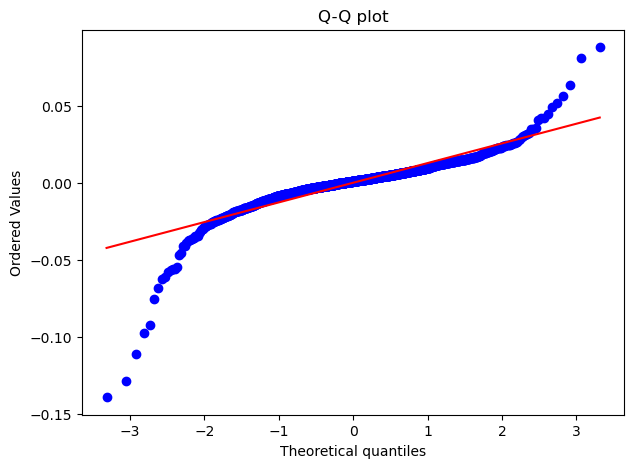

In [29]:
plt.subplots(figsize=(7,5))
stats.probplot(adx_data['Close_log_diff'][1:],dist='norm',plot=plt);
plt.title('Q-Q plot');

In [30]:
stats.shapiro(adx_data['Close_log_diff'][1:])

ShapiroResult(statistic=0.8178448975302012, pvalue=2.812987115917356e-38)

In [31]:
stats.jarque_bera(adx_data['Close_log_diff'][1:])

SignificanceResult(statistic=24625.062803128214, pvalue=0.0)

In [32]:
y2= adx_data['Close_log_diff'][1:]
x2= np.arange(len(y2))
x2=sm.add_constant(x2)

model2= sm.OLS(y2,x2).fit()

white_test2= het_white(model2.resid, model2.model.exog)


In [33]:
white_test2

(7.490401478158695,
 0.02363088492944451,
 3.7564085680404666,
 0.02358689928048032)

In [34]:
adfuller(adx_data['Close_log_diff'][1:])

(-11.9333019581327,
 4.72575553619426e-22,
 8,
 1499,
 {'1%': -3.4347199356122493,
  '5%': -2.86347004827819,
  '10%': -2.567797534300163},
 -8498.009185255369)

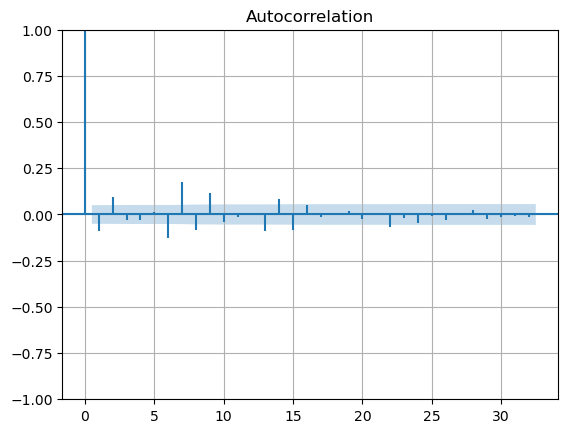

In [35]:
plot_acf(adx_data['Close_log_diff'][1:],marker='');
plt.grid()

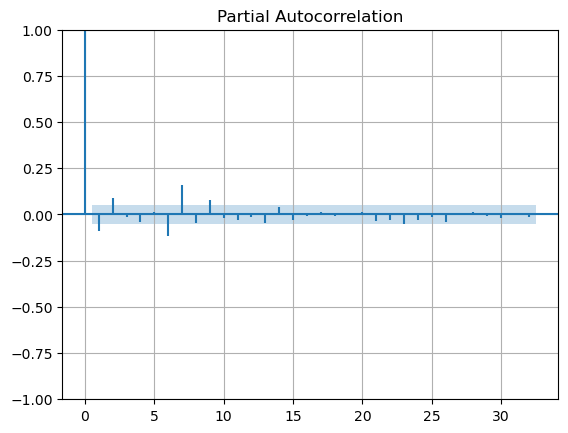

In [36]:
plot_pacf(adx_data['Close_log_diff'][1:],marker='');
plt.grid()

In [38]:
acorr_ljungbox(adx_data['Close_log_diff'][1:],return_df=True,lags=[30])

,lb_stat,lb_pvalue
30,187.996564,8.500651e-25


In [39]:
import pmdarima as pm
auto_arima_model = pm.auto_arima(adx_data['Close_log_diff'][1:], 
                      
                          stepwise=True,   
                          
                          trace=True)      
print(auto_arima_model.summary())

Performing stepwise search to minimize aic
 ARIMA(2,0,2)(0,0,0)[0] intercept   : AIC=-8578.930, Time=1.56 sec
 ARIMA(0,0,0)(0,0,0)[0] intercept   : AIC=-8565.210, Time=0.18 sec
 ARIMA(1,0,0)(0,0,0)[0] intercept   : AIC=-8575.568, Time=0.17 sec
 ARIMA(0,0,1)(0,0,0)[0] intercept   : AIC=-8573.649, Time=0.39 sec
 ARIMA(0,0,0)(0,0,0)[0]             : AIC=-8567.126, Time=0.09 sec
 ARIMA(1,0,2)(0,0,0)[0] intercept   : AIC=-8584.164, Time=0.99 sec
 ARIMA(0,0,2)(0,0,0)[0] intercept   : AIC=-8584.926, Time=0.81 sec
 ARIMA(0,0,3)(0,0,0)[0] intercept   : AIC=-8584.527, Time=1.55 sec
 ARIMA(1,0,1)(0,0,0)[0] intercept   : AIC=-8580.454, Time=0.84 sec
 ARIMA(1,0,3)(0,0,0)[0] intercept   : AIC=-8582.503, Time=1.75 sec
 ARIMA(0,0,2)(0,0,0)[0]             : AIC=-8586.843, Time=0.45 sec
 ARIMA(0,0,1)(0,0,0)[0]             : AIC=-8575.549, Time=0.15 sec
 ARIMA(1,0,2)(0,0,0)[0]             : AIC=-8586.077, Time=0.53 sec
 ARIMA(0,0,3)(0,0,0)[0]             : AIC=-8586.424, Time=0.57 sec
 ARIMA(1,0,1)(0,0,0

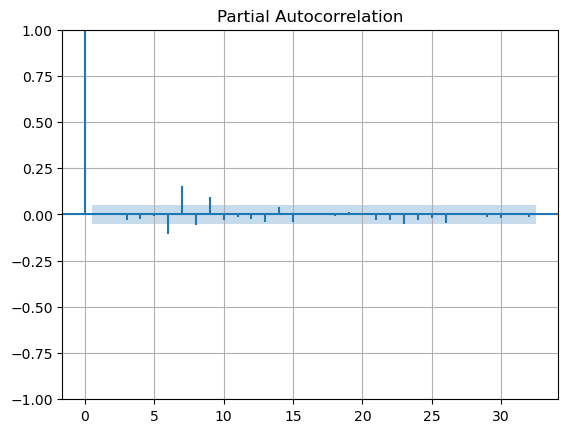

In [40]:
plot_pacf(auto_arima_model.resid(),marker='')
plt.grid()

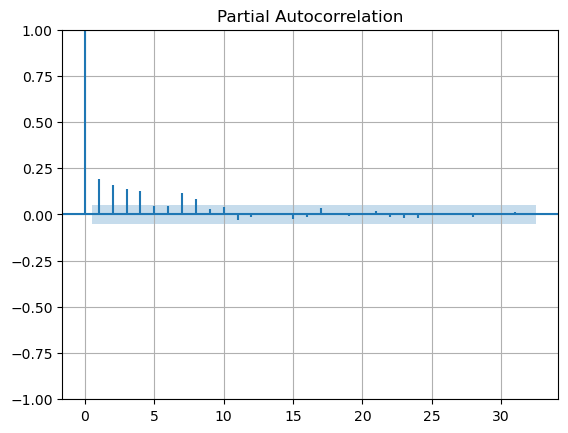

In [41]:
plot_pacf(auto_arima_model.resid()**2,marker='')
plt.grid()

In [42]:
from statsmodels.stats.diagnostic import het_arch

In [43]:
het_arch(auto_arima_model.resid())

(173.54971900141254,
 5.102346706382061e-32,
 19.48494676300919,
 4.215584873075201e-34)

In [44]:
from arch import arch_model

garch_model = arch_model(adx_data['Close_log_diff'][1:],
                        vol='GARCH',
                        mean='Constant', 
                        p=1 , q=1,
                        rescale=True,
                        dist='studentst'
                        ).fit(update_freq=0)

print(garch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2144.7851466189627
            Iterations: 15
            Function evaluations: 106
            Gradient evaluations: 15
                        Constant Mean - GARCH Model Results                         
Dep. Variable:               Close_log_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -2144.79
Distribution:      Standardized Student's t   AIC:                           4299.57
Method:                  Maximum Likelihood   BIC:                           4326.16
                                              No. Observations:                 1508
Date:                      Sun, Jul 19 2026   Df Residuals:                     1507
Time:                              21:09:59   Df Model:                            1
                        

In [45]:
egarch_model= arch_model(adx_data['Close_log_diff'][1:],
                         vol='EGARCH',
                         mean='Constant',
                         dist='studentst',
                         p=1, q=1,
                         rescale=True
                         ).fit(update_freq=0)

print(egarch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2148.104685162528
            Iterations: 16
            Function evaluations: 119
            Gradient evaluations: 16
                        Constant Mean - EGARCH Model Results                        
Dep. Variable:               Close_log_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2148.10
Distribution:      Standardized Student's t   AIC:                           4306.21
Method:                  Maximum Likelihood   BIC:                           4332.80
                                              No. Observations:                 1508
Date:                      Sun, Jul 19 2026   Df Residuals:                     1507
Time:                              21:09:59   Df Model:                            1
                         

In [46]:
tgarch_model= arch_model(adx_data['Close_log_diff'][1:],
                        vol='GARCH',
                        mean='Constant',
                        dist='studentst',
                        p=1, q=1, o=1,
                        power=1.0,
                        rescale=True
                        ).fit(update_freq=0)

print(tgarch_model.summary())

Optimization terminated successfully    (Exit mode 0)
            Current function value: 2114.7067289712
            Iterations: 19
            Function evaluations: 152
            Gradient evaluations: 19
                     Constant Mean - TARCH/ZARCH Model Results                      
Dep. Variable:               Close_log_diff   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                      TARCH/ZARCH   Log-Likelihood:               -2114.71
Distribution:      Standardized Student's t   AIC:                           4241.41
Method:                  Maximum Likelihood   BIC:                           4273.32
                                              No. Observations:                 1508
Date:                      Sun, Jul 19 2026   Df Residuals:                     1507
Time:                              21:09:59   Df Model:                            1
                           

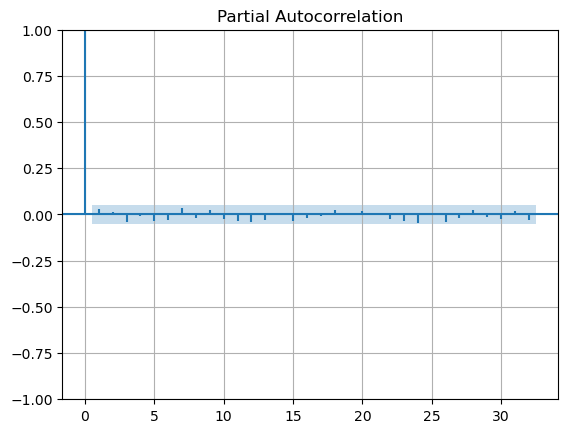

In [77]:
plot_pacf(garch_model.std_resid, marker='')
plt.grid()

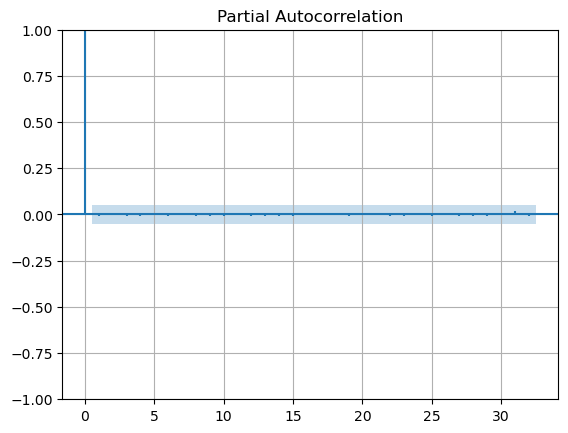

In [78]:
plot_pacf(garch_model.std_resid**2, marker='')
plt.grid()

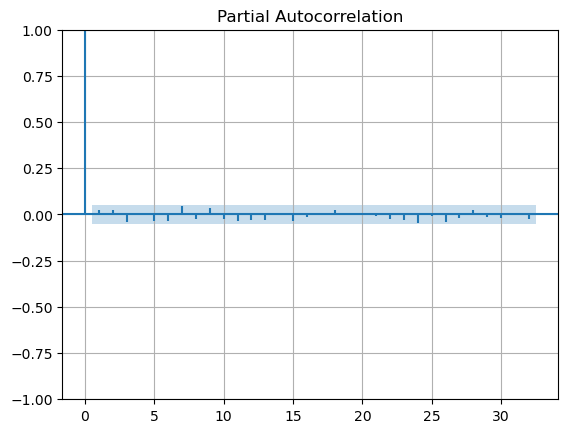

In [79]:
plot_pacf(egarch_model.std_resid, marker='')
plt.grid()

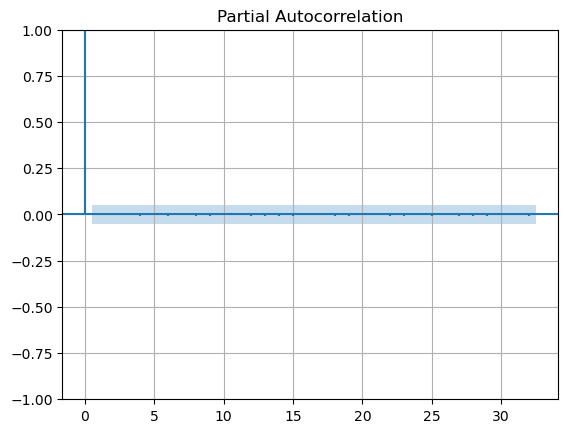

In [80]:
plot_pacf(egarch_model.std_resid**2, marker='')
plt.grid()

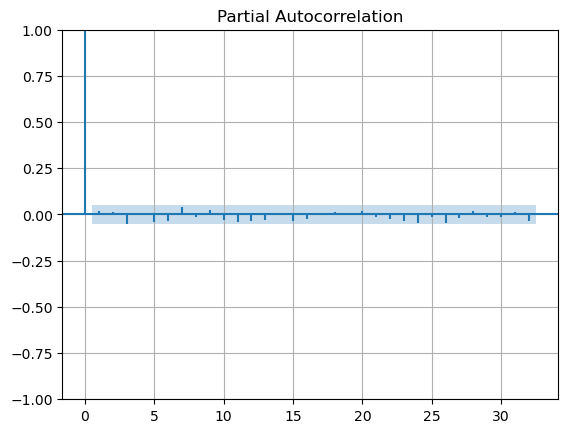

In [81]:
plot_pacf(tgarch_model.std_resid, marker='')
plt.grid()

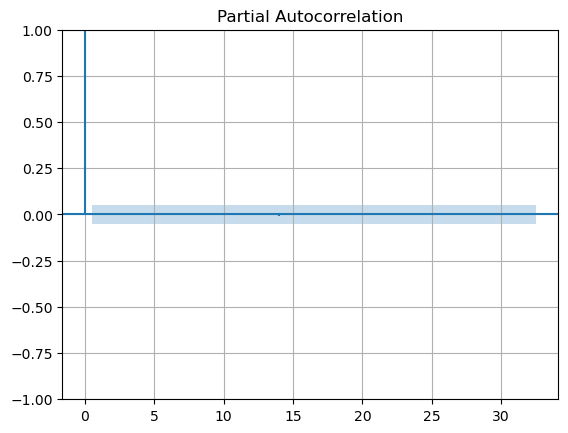

In [82]:
plot_pacf(tgarch_model.std_resid**2, marker='')
plt.grid()

In [89]:
acorr_ljungbox(tgarch_model.std_resid,return_df=True,lags=[1,23,39])

,lb_stat,lb_pvalue
1,0.630646,0.427118
23,26.766531,0.266032
39,37.684144,0.529857


In [88]:
acorr_ljungbox(tgarch_model.std_resid**2,return_df=True,lags=10)

,lb_stat,lb_pvalue
1,0.030408,0.861568
2,0.042937,0.978760
3,0.055634,0.996568
4,0.079471,0.999231
5,0.152311,0.999544
6,0.175494,0.999895
7,0.176710,0.999984
8,0.202137,0.999996
9,0.227733,0.999999
10,0.236730,1.000000


In [90]:
het_arch(tgarch_model.std_resid)

(0.23560947212354244,
 0.9999998285814816,
 0.023391615347733985,
 0.9999998324096153)